<a href="https://colab.research.google.com/github/Professori1086/Machine-learning/blob/main/END_TO_END_ML_REGRESSION_USING_EURCAD_DATA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# END TO END PROJECT ON THE BREAKOUT BACKTEST FOR THE EURUSD ON USING THE HOURLY CHART CANDLESTICKS

In [ ]:
# Import the necessary libraries

!pip install pandas_ta

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.3/240.3 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 102.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 76.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 12.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninst

In [ ]:
import datetime

print(f"Last notebook runtime :{datetime.datetime.now()}")

Last notebook runtime :2026-04-17 08:00:31.231666


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_ta as ta

In [ ]:
np.random.seed(42)

### Data download

In [ ]:
# Mount the drive on to the notebook in order to import the files
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!ls "/content/drive/My Drive"

'2021 Acknowledgements receipts'
 BLOCKCHAIN
'Business records'
'CODE TRADING'
'Colab Notebooks'
'DREAM CAR FOR FOREX'
'Employment Documents '
'FOREX DATA'
'FOREX JOURNAL'
'Hardware evidence'
 Images
 IMG_20220904_162951.jpg
 IMG_20220904_163008.jpg
 IMG_20240429_113915_910.jpg
 IMG_20260328_163451_418.jpg
 IT1_Individual_Resident_Return_XLS.xls
 junk
 Machine-learning-data
'my docs'
'Nyangi '
 PERSONAL
 peter-odhiambo-pdf-ticket-uIzcGH-05082024.pdf
'RHINO AGRIMAC WORK'
 S
 UnderstandingDeepLearning_04_18_24_C.pdf
 unspecified
'VAT receipts'
 WEBSITE
'WEEKLY REPORT COPY.xlsx'


In [ ]:
import os
os.chdir("/content/drive/My Drive/FOREX DATA")

In [ ]:
!ls

EURCAD_H1_201601040000_202603171400.csv
EURCAD_M1_201601040000_202603171421.csv
EURUSD_H1_201601040000_202603171300.csv
EURUSD_M1_201601040000_202603171425.csv
GBPCAD_H1_202001020600_202603171300.csv
GBPCAD_M15_201601040000_202603171400.csv
GBPUSD_H1_201601040000_202603171300.csv
GBPUSD_M15_201601040000_202603171330.csv
lr_model.pkl
my_trading_model.onnx
USDCAD_H1_201601040000_202603171400.csv
USDCAD_M15_201601040000_202603171400.csv
USDCHF_H1_201601040000_202603171300.csv
USDCHF_M15_201601040000_202603171345.csv


In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/My Drive/FOREX DATA/EURCAD_H1_201601040000_202603171400.csv", delimiter='\t')

In [ ]:
df.head()

,DATE,TIME,OPEN,HIGH,LOW,CLOSE,TICK VOL,VOL,SPREAD
0,2016.01.04,00:00:00,1.50158,1.50699,1.50158,1.50675,1384,1095400000,40
1,2016.01.04,01:00:00,1.50686,1.50686,1.50211,1.50543,3531,2673850000,20
2,2016.01.04,02:00:00,1.50537,1.50585,1.50205,1.50400,4440,4155400000,19
3,2016.01.04,03:00:00,1.50404,1.51034,1.50352,1.51025,4901,4147000000,19
4,2016.01.04,04:00:00,1.51025,1.51202,1.50961,1.51059,5046,4340000000,19


In [ ]:
df.columns


Index(['DATE', 'TIME', 'OPEN', 'HIGH', 'LOW', 'CLOSE', 'TICK VOL', 'VOL',
       'SPREAD'],
      dtype='str')

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 63486 entries, 0 to 63485
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   DATE      63486 non-null  str    
 1   TIME      63486 non-null  str    
 2   OPEN      63486 non-null  float64
 3   HIGH      63486 non-null  float64
 4   LOW       63486 non-null  float64
 5   CLOSE     63486 non-null  float64
 6   TICK VOL  63486 non-null  int64  
 7   VOL       63486 non-null  int64  
 8   SPREAD    63486 non-null  int64  
dtypes: float64(4), int64(3), str(2)
memory usage: 5.4 MB


In [ ]:
df.shape

(63486, 9)

In [ ]:
df.describe()

,OPEN,HIGH,LOW,CLOSE,TICK VOL,VOL,SPREAD
count,63486.000000,63486.000000,63486.000000,63486.000000,63486.000000,6.348600e+04,63486.000000
mean,1.487158,1.488161,1.486192,1.487173,5864.542151,6.119951e+08,9.845226
std,0.064652,0.064661,0.064645,0.064659,5045.173849,1.865603e+09,13.345229
min,1.288470,1.289750,1.287560,1.288470,1.000000,0.000000e+00,0.000000
25%,1.454292,1.455242,1.453310,1.454310,2478.000000,0.000000e+00,1.000000
50%,1.482150,1.483030,1.481260,1.482170,4480.000000,0.000000e+00,5.000000
75%,1.524100,1.525220,1.522960,1.524100,7784.000000,0.000000e+00,19.000000
max,1.645750,1.646730,1.644870,1.645760,95122.000000,2.046230e+10,437.000000


In [ ]:
df.dtypes


DATE            str
TIME            str
OPEN        float64
HIGH        float64
LOW         float64
CLOSE       float64
TICK VOL      int64
VOL           int64
SPREAD        int64
dtype: object

### Feature Engineering

In [ ]:
import pandas_ta as ta

In [ ]:
df['True Range'] = ta.true_range(df['HIGH'], df['LOW'], df['CLOSE'])

df.head()

,DATE,TIME,OPEN,HIGH,LOW,CLOSE,TICK VOL,VOL,SPREAD,True Range
0,2016.01.04,00:00:00,1.50158,1.50699,1.50158,1.50675,1384,1095400000,40,0.00541
1,2016.01.04,01:00:00,1.50686,1.50686,1.50211,1.50543,3531,2673850000,20,0.00475
2,2016.01.04,02:00:00,1.50537,1.50585,1.50205,1.50400,4440,4155400000,19,0.00380
3,2016.01.04,03:00:00,1.50404,1.51034,1.50352,1.51025,4901,4147000000,19,0.00682
4,2016.01.04,04:00:00,1.51025,1.51202,1.50961,1.51059,5046,4340000000,19,0.00241


In [ ]:
df.drop(columns=['TICK VOL','VOL'], inplace = True)
df.head()


,DATE,TIME,OPEN,HIGH,LOW,CLOSE,SPREAD,True Range
0,2016.01.04,00:00:00,1.50158,1.50699,1.50158,1.50675,40,0.00541
1,2016.01.04,01:00:00,1.50686,1.50686,1.50211,1.50543,20,0.00475
2,2016.01.04,02:00:00,1.50537,1.50585,1.50205,1.50400,19,0.00380
3,2016.01.04,03:00:00,1.50404,1.51034,1.50352,1.51025,19,0.00682
4,2016.01.04,04:00:00,1.51025,1.51202,1.50961,1.51059,19,0.00241


In [ ]:
df2 = df.copy()

In [ ]:
df2['DATE TIME'] = pd.to_datetime(df['DATE'] + ' ' + df['TIME'])
df2.head()

,DATE,TIME,OPEN,HIGH,LOW,CLOSE,SPREAD,True Range,DATE TIME
0,2016.01.04,00:00:00,1.50158,1.50699,1.50158,1.50675,40,0.00541,2016-01-04 00:00:00
1,2016.01.04,01:00:00,1.50686,1.50686,1.50211,1.50543,20,0.00475,2016-01-04 01:00:00
2,2016.01.04,02:00:00,1.50537,1.50585,1.50205,1.50400,19,0.00380,2016-01-04 02:00:00
3,2016.01.04,03:00:00,1.50404,1.51034,1.50352,1.51025,19,0.00682,2016-01-04 03:00:00
4,2016.01.04,04:00:00,1.51025,1.51202,1.50961,1.51059,19,0.00241,2016-01-04 04:00:00


In [ ]:
df.isna().sum()

DATE          0
TIME          0
OPEN          0
HIGH          0
LOW           0
CLOSE         0
SPREAD        0
True Range    0
dtype: int64

In [ ]:
df2.drop(columns=['DATE','TIME'], inplace=True)
df2.head()

,OPEN,HIGH,LOW,CLOSE,SPREAD,True Range,DATE TIME
0,1.50158,1.50699,1.50158,1.50675,40,0.00541,2016-01-04 00:00:00
1,1.50686,1.50686,1.50211,1.50543,20,0.00475,2016-01-04 01:00:00
2,1.50537,1.50585,1.50205,1.50400,19,0.00380,2016-01-04 02:00:00
3,1.50404,1.51034,1.50352,1.51025,19,0.00682,2016-01-04 03:00:00
4,1.51025,1.51202,1.50961,1.51059,19,0.00241,2016-01-04 04:00:00


In [ ]:
df2.insert(0,'DATE TIME',df2.pop('DATE TIME'))
df2.head()

,DATE TIME,OPEN,HIGH,LOW,CLOSE,SPREAD,True Range
0,2016-01-04 00:00:00,1.50158,1.50699,1.50158,1.50675,40,0.00541
1,2016-01-04 01:00:00,1.50686,1.50686,1.50211,1.50543,20,0.00475
2,2016-01-04 02:00:00,1.50537,1.50585,1.50205,1.50400,19,0.00380
3,2016-01-04 03:00:00,1.50404,1.51034,1.50352,1.51025,19,0.00682
4,2016-01-04 04:00:00,1.51025,1.51202,1.50961,1.51059,19,0.00241


## Viewing the dataframe using matplotlib library so as to see how the candlesticks look like visually

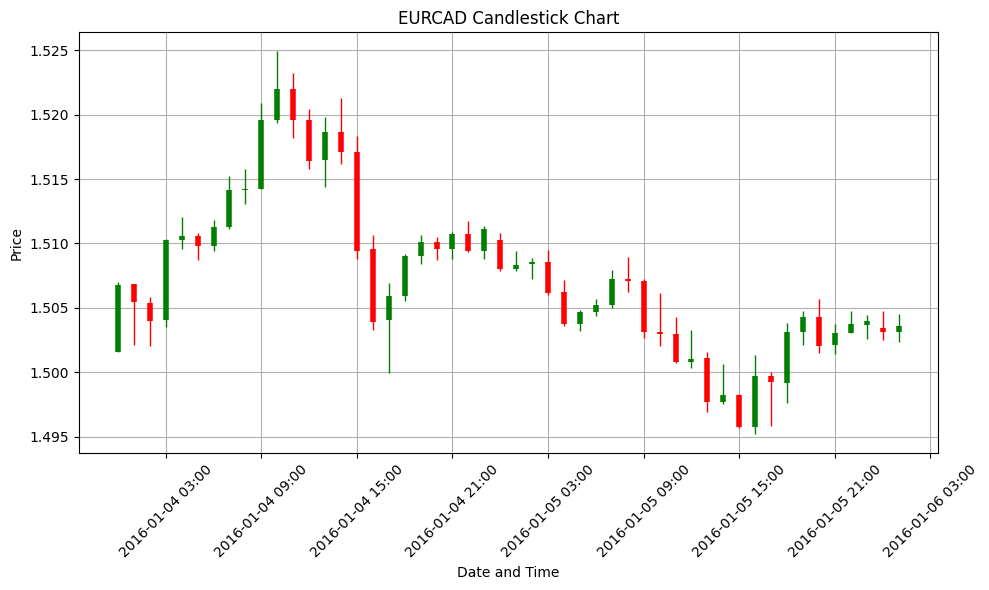

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
%matplotlib inline

def plot_candlesticks(df, ax):
    # Convert datetime to matplotlib's internal numerical format
    df['Date_mpl'] = df['DATE TIME'].apply(lambda x: mdates.date2num(x))

    # Iterate over the rows of the DataFrame to draw each candlestick
    for index, row in df.iterrows():
        date = row['Date_mpl']
        open_price = row['OPEN']
        close_price = row['CLOSE']
        high_price = row['HIGH']
        low_price = row['LOW']

        # Determine color based on whether the candle is 'up' (green) or 'down' (red)
        color = 'green' if close_price > open_price else 'red'

        # Draw the body of the candle
        ax.vlines(date, min(open_price, close_price), max(open_price, close_price), color=color, linewidth=4)
        # Draw the wick (high and low)
        ax.vlines(date, low_price, high_price, color=color, linewidth=1)

    # Format the x-axis to show dates nicely
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=6)) # Show every 6 hours
    ax.tick_params(axis='x', rotation=45)

    ax.set_xlabel('Date and Time')
    ax.set_ylabel('Price')
    ax.set_title('EURCAD Candlestick Chart')
    ax.grid(True)

# Create a figure and an axes object
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the candlesticks
# For demonstration, let's plot a subset of the data, e.g., the first 50 candles
plot_candlesticks(df2.head(50), ax)

plt.tight_layout()
plt.show()

## Model development

In [ ]:
# Creating more feature columns to help in the training of the selected models

df2['MA 10'] = df2['CLOSE'].rolling(window=10).mean()
df2['MA 40'] = df2['CLOSE'].rolling(window=40).mean()
df2['RETURNS'] = df2.CLOSE.pct_change()
df['VOLATILITY'] = df2.RETURNS.rolling(window=20).std()

df2.head()

,DATE TIME,OPEN,HIGH,LOW,CLOSE,SPREAD,True Range,MA 10,MA 40,RETURNS
0,2016-01-04 00:00:00,1.50158,1.50699,1.50158,1.50675,40,0.00541,NaN,NaN,NaN
1,2016-01-04 01:00:00,1.50686,1.50686,1.50211,1.50543,20,0.00475,NaN,NaN,-0.000876
2,2016-01-04 02:00:00,1.50537,1.50585,1.50205,1.50400,19,0.00380,NaN,NaN,-0.000950
3,2016-01-04 03:00:00,1.50404,1.51034,1.50352,1.51025,19,0.00682,NaN,NaN,0.004156
4,2016-01-04 04:00:00,1.51025,1.51202,1.50961,1.51059,19,0.00241,NaN,NaN,0.000225


In [ ]:
# Adding lag columns
for lag in [1,5,10,15]:
  df2[f'CLOSE_LAG_{lag}'] = df2['CLOSE'].shift(lag)
df2.head()

,DATE TIME,OPEN,HIGH,LOW,CLOSE,SPREAD,True Range,MA 10,MA 40,RETURNS,CLOSE_LAG_1,CLOSE_LAG_5,CLOSE_LAG_10,CLOSE_LAG_15
0,2016-01-04 00:00:00,1.50158,1.50699,1.50158,1.50675,40,0.00541,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-01-04 01:00:00,1.50686,1.50686,1.50211,1.50543,20,0.00475,NaN,NaN,-0.000876,1.50675,NaN,NaN,NaN
2,2016-01-04 02:00:00,1.50537,1.50585,1.50205,1.50400,19,0.00380,NaN,NaN,-0.000950,1.50543,NaN,NaN,NaN
3,2016-01-04 03:00:00,1.50404,1.51034,1.50352,1.51025,19,0.00682,NaN,NaN,0.004156,1.50400,NaN,NaN,NaN
4,2016-01-04 04:00:00,1.51025,1.51202,1.50961,1.51059,19,0.00241,NaN,NaN,0.000225,1.51025,NaN,NaN,NaN


In [ ]:
# Dropping the Nan values
df2.dropna(inplace=True)
df2.head()

,DATE TIME,OPEN,HIGH,LOW,CLOSE,SPREAD,True Range,MA 10,MA 40,RETURNS,CLOSE_LAG_1,CLOSE_LAG_5,CLOSE_LAG_10,CLOSE_LAG_15
39,2016-01-05 15:00:00,1.49820,1.49827,1.49570,1.49573,19,0.00257,1.501908,1.508441,-0.001649,1.49820,1.50293,1.50466,1.50800
40,2016-01-05 16:00:00,1.49573,1.50132,1.49521,1.49971,19,0.00611,1.501356,1.508265,0.002661,1.49573,1.50082,1.50523,1.50835
41,2016-01-05 17:00:00,1.49970,1.50003,1.49583,1.49924,0,0.00420,1.500556,1.508110,-0.000313,1.49971,1.50104,1.50724,1.50858
42,2016-01-05 18:00:00,1.49919,1.50379,1.49762,1.50311,19,0.00617,1.500158,1.508088,0.002581,1.49924,1.49768,1.50709,1.50617
43,2016-01-05 19:00:00,1.50310,1.50477,1.50214,1.50431,19,0.00263,1.500277,1.507939,0.000798,1.50311,1.49820,1.50312,1.50372


In [ ]:
# Reseting the index on the new dataframe
df2.reset_index(drop=True, inplace=True)
df2.head()

,DATE TIME,OPEN,HIGH,LOW,CLOSE,SPREAD,True Range,MA 10,MA 40,RETURNS,CLOSE_LAG_1,CLOSE_LAG_5,CLOSE_LAG_10,CLOSE_LAG_15
0,2016-01-05 15:00:00,1.49820,1.49827,1.49570,1.49573,19,0.00257,1.501908,1.508441,-0.001649,1.49820,1.50293,1.50466,1.50800
1,2016-01-05 16:00:00,1.49573,1.50132,1.49521,1.49971,19,0.00611,1.501356,1.508265,0.002661,1.49573,1.50082,1.50523,1.50835
2,2016-01-05 17:00:00,1.49970,1.50003,1.49583,1.49924,0,0.00420,1.500556,1.508110,-0.000313,1.49971,1.50104,1.50724,1.50858
3,2016-01-05 18:00:00,1.49919,1.50379,1.49762,1.50311,19,0.00617,1.500158,1.508088,0.002581,1.49924,1.49768,1.50709,1.50617
4,2016-01-05 19:00:00,1.50310,1.50477,1.50214,1.50431,19,0.00263,1.500277,1.507939,0.000798,1.50311,1.49820,1.50312,1.50372


In [ ]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 63447 entries, 0 to 63446
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   DATE TIME     63447 non-null  datetime64[us]
 1   OPEN          63447 non-null  float64       
 2   HIGH          63447 non-null  float64       
 3   LOW           63447 non-null  float64       
 4   CLOSE         63447 non-null  float64       
 5   SPREAD        63447 non-null  int64         
 6   True Range    63447 non-null  float64       
 7   MA 10         63447 non-null  float64       
 8   MA 40         63447 non-null  float64       
 9   RETURNS       63447 non-null  float64       
 10  CLOSE_LAG_1   63447 non-null  float64       
 11  CLOSE_LAG_5   63447 non-null  float64       
 12  CLOSE_LAG_10  63447 non-null  float64       
 13  CLOSE_LAG_15  63447 non-null  float64       
dtypes: datetime64[us](1), float64(12), int64(1)
memory usage: 6.8 MB


In [ ]:
feature_columns = ['OPEN','HIGH','LOW','True Range','MA 10','MA 40','RETURNS',
                   'CLOSE_LAG_1','CLOSE_LAG_5','CLOSE_LAG_10','CLOSE_LAG_15']
target_column = 'CLOSE'

####Data preprocessing

In [ ]:
# Split the features and the target
X = df2[feature_columns]
Y = df2[target_column]

In [ ]:
# train-test split (use chronological split)
split_index = int(0.8 * len(df2))
X_train, X_test = X[:split_index], X[split_index:]
Y_train, Y_test = Y[:split_index], Y[split_index:]

In [ ]:
# Scale the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
X_train[:5]

array([[ 0.43497072,  0.41800844,  0.40937859,  0.33480353,  0.49918293,
         0.61291904, -1.60952028,  0.43482668,  0.51658878,  0.54643861,
         0.60412895],
       [ 0.39224979,  0.47072829,  0.40089734,  2.59088176,  0.48963047,
         0.60986891,  2.59740044,  0.39210533,  0.48009434,  0.55629715,
         0.61018234],
       [ 0.4609146 ,  0.44843039,  0.41162871,  1.37361921,  0.47578633,
         0.60718705, -0.30606828,  0.46094378,  0.48389945,  0.59106147,
         0.61416028],
       [ 0.45209368,  0.51342272,  0.44261122,  2.62912038,  0.46889887,
         0.60680145,  2.51969594,  0.45281462,  0.42578508,  0.58846712,
         0.57247838],
       [ 0.51972074,  0.53036221,  0.52084639,  0.37304214,  0.47095818,
         0.6042279 ,  0.77919426,  0.5197505 ,  0.43477897,  0.51980326,
         0.53010466]])

In [ ]:
X_train_scaled = pd.DataFrame(X_train, columns=feature_columns)
X_test_scaled = pd.DataFrame(X_test, columns=feature_columns)
X_train_scaled.head()

,OPEN,HIGH,LOW,True Range,MA 10,MA 40,RETURNS,CLOSE_LAG_1,CLOSE_LAG_5,CLOSE_LAG_10,CLOSE_LAG_15
0,0.434971,0.418008,0.409379,0.334804,0.499183,0.612919,-1.609520,0.434827,0.516589,0.546439,0.604129
1,0.392250,0.470728,0.400897,2.590882,0.489630,0.609869,2.597400,0.392105,0.480094,0.556297,0.610182
2,0.460915,0.448430,0.411629,1.373619,0.475786,0.607187,-0.306068,0.460944,0.483899,0.591061,0.614160
3,0.452094,0.513423,0.442611,2.629120,0.468899,0.606801,2.519696,0.452815,0.425785,0.588467,0.572478
4,0.519721,0.530362,0.520846,0.373042,0.470958,0.604228,0.779194,0.519751,0.434779,0.519803,0.530105


In [ ]:
X_test_scaled.head()

,OPEN,HIGH,LOW,True Range,MA 10,MA 40,RETURNS,CLOSE_LAG_1,CLOSE_LAG_5,CLOSE_LAG_10,CLOSE_LAG_15
0,-0.066092,-0.064421,-0.067475,0.105372,-0.080869,-0.071779,-0.644581,-0.064512,-0.091018,-0.100766,-0.095989
1,-0.080967,-0.094670,-0.086688,-0.302507,-0.078447,-0.073400,-0.159693,-0.081289,-0.077354,-0.109760,-0.087687
2,-0.085810,-0.089485,-0.075437,-0.525565,-0.077391,-0.074128,0.505203,-0.085440,-0.083062,-0.082951,-0.099102
3,-0.072665,-0.072373,-0.058475,-0.519192,-0.076785,-0.074613,0.431838,-0.072295,-0.071127,-0.067212,-0.102215
4,-0.060212,-0.069607,-0.049301,-0.754997,-0.074190,-0.074929,0.265576,-0.061052,-0.064555,-0.080184,-0.097545


### Model training and comparison

In [ ]:
#Define models to compare
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor



In [ ]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
import numpy as np

np.random.seed(42)

results = {}

for name, model in models.items():
  # Train models
  print(f"\nTraining {name}...")
  model.fit(X_train_scaled, Y_train)

  # Predictions
  Y_pred_train = model.predict(X_train_scaled)
  Y_pred_test = model.predict(X_test_scaled)

  # Evaluation metrics for the various models
  results[name]= {
      'Train RMSE': np.sqrt(mean_squared_error(Y_train, Y_pred_train)),
      'Test RMSE': np.sqrt(mean_squared_error(Y_test, Y_pred_test)),
      'Train MAE': mean_absolute_error(Y_train, Y_pred_train),
      'Test MAE': mean_absolute_error(Y_test, Y_pred_test),
      'Train R2': r2_score(Y_train, Y_pred_train),
      'Test R2': r2_score(Y_test, Y_pred_test)
  }

  # Print individual model results
  print(f" Train RMSE: {results[name]['Train RMSE']:.4f}")
  print(f" Test RMSE: {results[name]['Test RMSE']:.4f}")
  print(f" Train MAE: {results[name]['Train MAE']:.4f}")
  print(f" Test MAE: {results[name]['Test MAE']:.4f}")
  print(f"Train R2: {results[name]['Train R2']:.4f}")
  print(f"Test R2: {results[name]['Test R2']:.4f}")


Training Linear Regression...
 Train RMSE: 0.0001
 Test RMSE: 0.0001
 Train MAE: 0.0000
 Test MAE: 0.0000
Train R2: 1.0000
Test R2: 1.0000

Training Ridge Regression...
 Train RMSE: 0.0001
 Test RMSE: 0.0001
 Train MAE: 0.0001
 Test MAE: 0.0001
Train R2: 1.0000
Test R2: 1.0000

Training Lasso Regression...
 Train RMSE: 0.0578
 Test RMSE: 0.0924
 Train MAE: 0.0435
 Test MAE: 0.0716
Train R2: 0.0000
Test R2: -1.3932

Training Random Forest...
 Train RMSE: 0.0002
 Test RMSE: 0.0050
 Train MAE: 0.0001
 Test MAE: 0.0020
Train R2: 1.0000
Test R2: 0.9930

Training Gradient Boosting...
 Train RMSE: 0.0008
 Test RMSE: 0.0055
 Train MAE: 0.0006
 Test MAE: 0.0025
Train R2: 0.9998
Test R2: 0.9916


In [ ]:
results_df= pd.DataFrame(results)
results_df.head()

,Linear Regression,Ridge Regression,Lasso Regression,Random Forest,Gradient Boosting
Train RMSE,0.000065,0.000123,0.057816,0.000153,0.000762
Test RMSE,0.000068,0.000126,0.092399,0.004985,0.005467
Train MAE,0.000032,0.000063,0.043497,0.000088,0.000575
Test MAE,0.000037,0.000069,0.071630,0.001985,0.002481
Train R2,0.999999,0.999995,0.000000,0.999993,0.999826


In [ ]:
results_df.T

,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2
Linear Regression,0.000065,0.000068,0.000032,0.000037,0.999999,0.999999
Ridge Regression,0.000123,0.000126,0.000063,0.000069,0.999995,0.999996
Lasso Regression,0.057816,0.092399,0.043497,0.071630,0.000000,-1.393242
Random Forest,0.000153,0.004985,0.000088,0.001985,0.999993,0.993033
Gradient Boosting,0.000762,0.005467,0.000575,0.002481,0.999826,0.991621


In [ ]:
# Find the best model
best_model = min(results, key=lambda k: results[k]['Test RMSE'])
print(f"The best model is {best_model}")
print(f"Test RMSE: {results[best_model]['Test RMSE']:.4f}")
print(f"Test MAE: {results[best_model]['Test MAE']:.4f}")
print(f"Test R2: {results[best_model]['Test R2']:.4f}")

The best model is Linear Regression
Test RMSE: 0.0001
Test MAE: 0.0000
Test R2: 1.0000


### Visualizing the initial best model

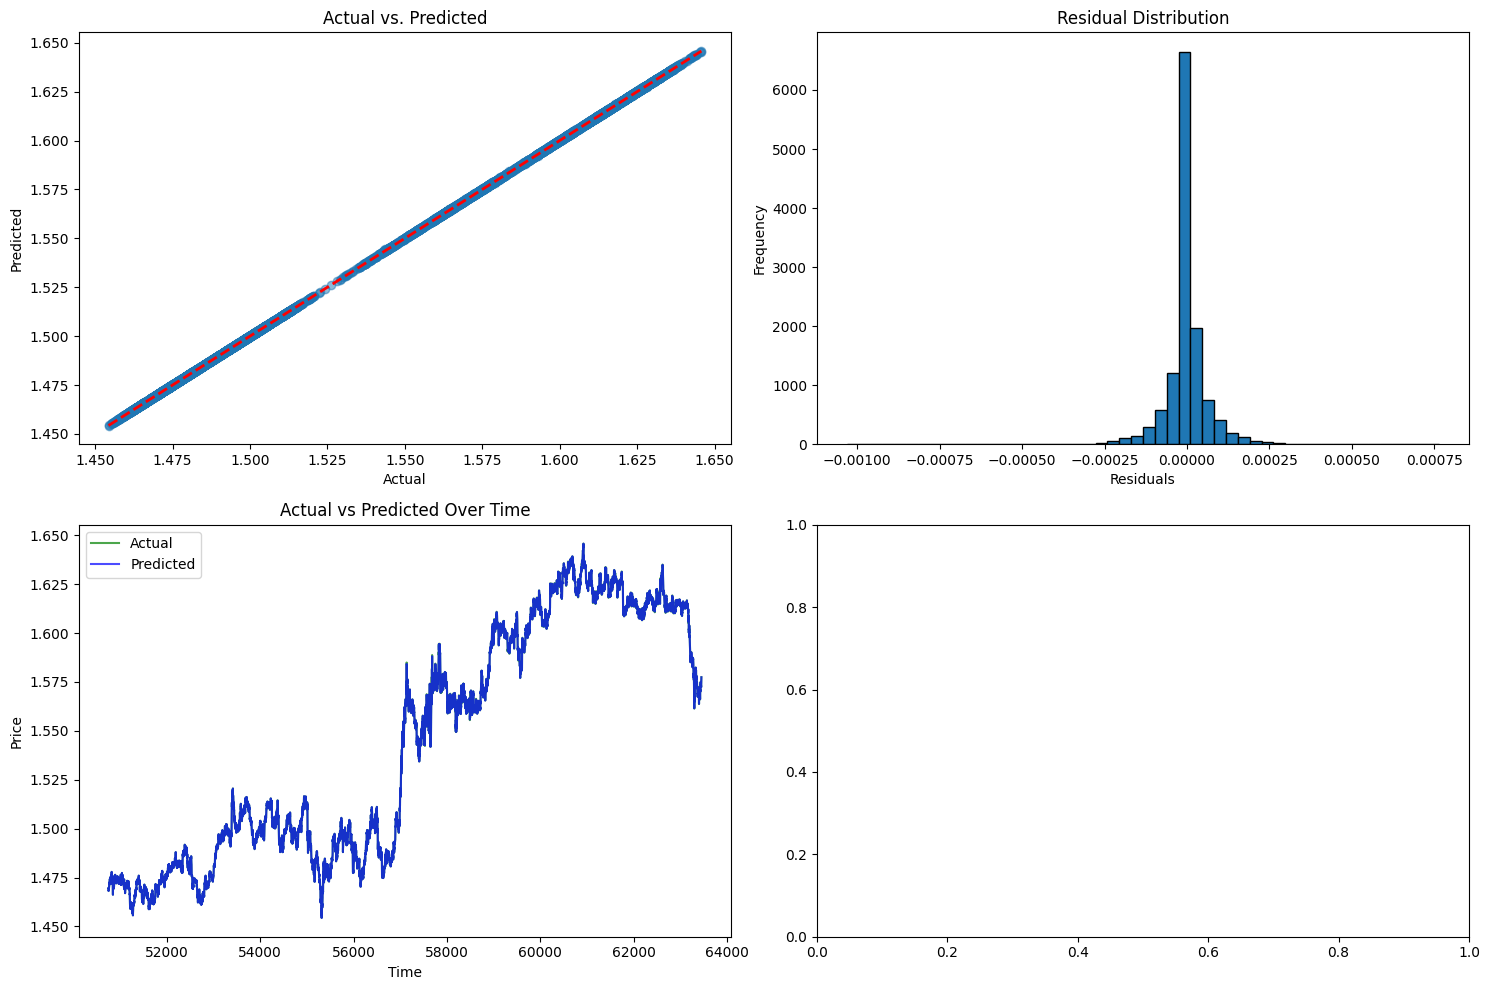

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

# Get predictions for the linear regression model
model_1 = LinearRegression()
model_1.fit(X_train_scaled, Y_train)
y_lin_pred = model_1.predict(X_test_scaled)

# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(15,10))

# Actual versus predicted
axes[0,0].scatter(Y_test, y_lin_pred, alpha=0.5)
axes[0,0].plot([Y_test.min(),Y_test.max()],[Y_test.min(),Y_test.max()], 'r--', lw=2)
axes[0,0].set_xlabel('Actual')
axes[0,0].set_ylabel('Predicted')
axes[0,0].set_title('Actual vs. Predicted')

# Residuals
residuals = Y_test - y_lin_pred
axes[0,1].hist(residuals, bins=50, edgecolor='black')
axes[0,1].set_xlabel('Residuals')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title('Residual Distribution')

# Time series plot
axes[1,0].plot(Y_test.index, Y_test, label='Actual', color='green', alpha=0.7)
axes[1,0].plot(Y_test.index, y_lin_pred, label='Predicted',color='blue', alpha=0.7)
axes[1,0].set_xlabel('Time')
axes[1,0].set_ylabel('Price')
axes[1,0].legend()
axes[1,0].set_title('Actual vs Predicted Over Time')

plt.tight_layout()
plt.show()

In [ ]:
best_model

'Linear Regression'

In [ ]:
Y_test.shape

(12690,)

In [ ]:
Y_test.reset_index(drop=True, inplace=True)
Y_test.head()

0    1.46836
1    1.46812
2    1.46888
3    1.46953
4    1.46993
Name: CLOSE, dtype: float64

In [ ]:
X_test_scaled.shape

(12690, 11)

In [ ]:
X_test_scaled.loc[0]

OPEN           -0.066092
HIGH           -0.064421
LOW            -0.067475
True Range      0.105372
MA 10          -0.080869
MA 40          -0.071779
RETURNS        -0.644581
CLOSE_LAG_1    -0.064512
CLOSE_LAG_5    -0.091018
CLOSE_LAG_10   -0.100766
CLOSE_LAG_15   -0.095989
Name: 0, dtype: float64

In [ ]:
lr=LinearRegression()
lr.fit(X_train_scaled, Y_train)
lr.predict(X_test_scaled.loc[[0]])

array([1.46836213])

In [ ]:
Y_test.loc[0]

np.float64(1.46836)

The predictions are really close to the actual test values. i believe the model is good to go. what remains is saving the model and using it on mql5.

In [ ]:
# saving the model
import joblib
joblib.dump(lr, 'lr_model.pkl')

['lr_model.pkl']

## Converting the model to ONNX  for use in mql5

In [ ]:
!pip install skl2onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 93.6 MB/s eta 0:00:00


In [ ]:
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

# Define input type
initial_type = [('float_input', FloatTensorType([1,X_train_scaled.shape[1]]))]

# Convert the model
onx = convert_sklearn(lr, initial_types=initial_type)

# Save the model to a file
with open("my_trading_model.onnx","wb")as f:
  f.write(onx.SerializeToString())

print("Model converted and saved as 'my_trading_model.onnx'")

Model converted and saved as 'my_trading_model.onnx'


In [ ]:
# Download the file to my computer
from google.colab import files
#files.download("my_trading_model.onnx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>